In [1]:
%load_ext autoreload
%autoreload 2
import sys
sys.path.append('../')
import mlflow
import torch
from src.utils import helpers
from src.utils import visualization as vis
from src.utils.model_registry import MLFlowRegistry
from src.core.params import BaseParams
from src.core.exported_model import ExportedModel
from src.data.datamodule import CrowdDataModule

In [2]:
model, params = MLFlowRegistry().load_model('crowd_counting', version='20', run_id='ab6237844ec24a4d92cb31e9c329d177')

/home/zeus/miniconda3/envs/cloudspace/lib/python3.13/site-packages/torch/export/pt2_archive/_package.py:790: UserWarning: The given buffer is not writable, and PyTorch does not support non-writable tensors. This means you can write to the underlying (supposedly non-writable) buffer using the tensor. You may want to copy the buffer to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:1586.)
  tensor = torch.frombuffer(


Model loaded from /teamspace/studios/this_studio/workspace/crowd_counting/trained_models/crowd_counting:20//data/model.pt2


In [3]:
model.predict(torch.randn(1,3,512,256))

(752.7109375,
 tensor([[[0.0045, 0.0049, 0.0058,  ..., 0.0040, 0.0032, 0.0028],
          [0.0052, 0.0057, 0.0068,  ..., 0.0046, 0.0037, 0.0032],
          [0.0067, 0.0074, 0.0089,  ..., 0.0058, 0.0046, 0.0041],
          ...,
          [0.0046, 0.0051, 0.0060,  ..., 0.0084, 0.0066, 0.0057],
          [0.0036, 0.0040, 0.0046,  ..., 0.0064, 0.0050, 0.0044],
          [0.0032, 0.0034, 0.0040,  ..., 0.0054, 0.0043, 0.0037]]],
        device='cuda:0'))

In [4]:
datamodule = CrowdDataModule(params=params)
datamodule.setup(stage='fit')

In [12]:
sample, target, count = helpers.get_sample_from_dm(datamodule, index=2)
sample.shape

torch.Size([1, 3, 672, 1024])

In [13]:
result_count, result  = model.predict(sample)
(result_count, result)

(249.66920471191406,
 tensor([[[2.8559e-04, 2.0823e-04, 1.0755e-04,  ..., 1.7777e-04,
           2.4883e-04, 2.9302e-04],
          [2.3436e-04, 1.6327e-04, 7.6944e-05,  ..., 1.1854e-04,
           1.8239e-04, 2.2497e-04],
          [1.5579e-04, 9.9027e-05, 3.8920e-05,  ..., 5.1322e-05,
           9.5630e-05, 1.2974e-04],
          ...,
          [9.7019e-05, 6.9373e-05, 3.5090e-05,  ..., 5.9994e-06,
           1.6197e-05, 2.6543e-05],
          [1.4559e-04, 1.1240e-04, 6.6296e-05,  ..., 1.7105e-05,
           3.8376e-05, 5.7242e-05],
          [1.7763e-04, 1.4245e-04, 9.0715e-05,  ..., 2.8794e-05,
           5.8793e-05, 8.3592e-05]]], device='cuda:0'))

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].


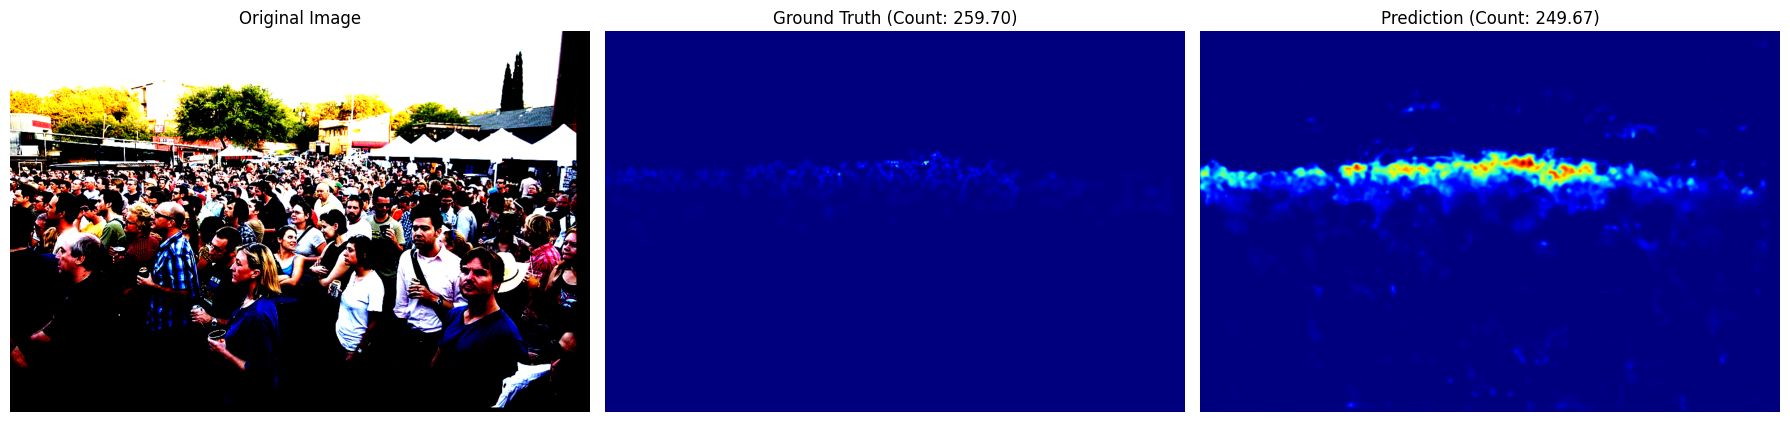

In [14]:
vis.visualize_sample(sample, target, result, count, result_count, )